In [1]:
import os
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab - Setting up environment...")
    from google.colab import drive
    drive.mount('/content/drive')
    
    repo_url = "https://github.com/pooyaht/dl_hw2"
    clone_path = "/content/drive/MyDrive/dl_hw2"
    
    if not os.path.exists(clone_path):
        print(f"Cloning repository to {clone_path}...")
        !git clone {repo_url} {clone_path}
    else:
        print(f"Repository already exists at {clone_path}")
    
    os.chdir(clone_path)
    print(f"Changed working directory to: {os.getcwd()}")
    
    if clone_path not in sys.path:
        sys.path.append(clone_path)
else:
    print("Running locally")
    

Running locally


In [ ]:
import torch
from tqdm import tqdm
from matplotlib import pyplot as plt

import json
from pathlib import Path
from datetime import datetime

from resnet_YOLO_model import SimpleResNetYOLO 
from coco_downloader import COCOCatDogDownloader
from dataloader import create_split_datasets, create_dataloaders
from yolo_helpers import create_yolo_targets, decode_yolo_predictions, yolo_loss, nms, calculate_anchors

In [26]:
def get_device():
    if torch.cuda.is_available():
        device = 'cuda'
        print(f"CUDA available: Using GPU - {torch.cuda.get_device_name()}")
    elif torch.backends.mps.is_available():
        device = 'mps'
        print("MPS available: Using Apple Silicon GPU")
    else:
        device = 'cpu'
        print("Using CPU")
    return device

experiment_config = {
    'model': 'resnet50',
    'num_anchors': 3,
    "grid_size": 14,
    'batch_size': 8,
    'num_epochs': 30,
    'val_ratio': 0.2,
    'unfreeze_partial_epoch': 12,  
    'unfreeze_all_epoch': 24,     
    'device': get_device(),
    'target_size': (448, 448),
    'lr_frozen': 1e-3,      
    'lr_partial': 1e-5,     
    'lr_all': 1e-6,         
    'weight_decay': 1e-3,  
    'dropout_rate': 0.4,
    'use_augmentation': True,
    'use_bg_removal': True,
    'bg_removal_p': 0.5,
    'coord_weight': 1,
    'augmentation_strength': 0.5
}

MPS available: Using Apple Silicon GPU


In [4]:
downloader = COCOCatDogDownloader()
downloader.download_and_prepare_dataset()

Annotations already exist, skipping download
loading annotations into memory...
Done (t=13.24s)
creating index...
index created!
Cat category ID: [17]
Dog category ID: [18]
Found 4078 pure cat images
Found 4342 pure dog images
Found 220 mixed images
Selected 220 mixed images (all)
Selected 2500 pure cat images
Selected 2500 pure dog images


100%|██████████| 5220/5220 [00:00<00:00, 51589.24it/s]


In [5]:
annotations_file = "cat_dog_images/cat_dog_annotations.json"

train_file, val_file = create_split_datasets(
    annotations_file, val_ratio=experiment_config['val_ratio'])

train_loader, val_loader = create_dataloaders(
    train_file, val_file, 
    batch_size=experiment_config['batch_size'],
    target_size=experiment_config['target_size'],
    use_albumentations=experiment_config['use_augmentation'],
    use_bg_removal=experiment_config['use_bg_removal'],
    augmentation_strength=experiment_config['augmentation_strength'],
    bg_removal_p=experiment_config['bg_removal_p']
)


Split Results:
Training set: 4176 images
- Mixed: 176
- Pure cat: 2000
- Pure dog: 2000
Validation set: 1044 images
- Mixed: 44
- Pure cat: 500
- Pure dog: 500

Saved:
- Training annotations: cat_dog_images/train_annotations.json
- Validation annotations: cat_dog_images/val_annotations.json


/Users/tobysmith/Desktop/Desktop/dev/python/ML/DL/HW2/.venv/lib/python3.13/site-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


In [ ]:
anchors = calculate_anchors(
    train_loader, 
    3, 
    experiment_config['grid_size'],
    experiment_config['target_size'][0]
)
print(anchors)

KeyboardInterrupt: 

In [14]:
def train_epoch(model, anchors, train_loader, optimizer, device, epoch):
    model.train()
    unfreeze_status = model.update_epoch(epoch)
    
    if unfreeze_status == 'unfreeze_partial':
        for param_group in optimizer.param_groups:
            param_group['lr'] = experiment_config['lr_partial']
        print(f"Learning rate changed to {experiment_config['lr_partial']:.1e}")
    elif unfreeze_status == 'unfreeze_all':
        for param_group in optimizer.param_groups:
            param_group['lr'] = experiment_config['lr_all']
        print(f"Learning rate changed to {experiment_config['lr_all']:.1e}")
    
    running_losses = {'total': 0.0, 'xy': 0.0, 'wh': 0.0, 'obj': 0.0, 'cls': 0.0}
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}')
    
    for batch_idx, (images, targets) in enumerate(pbar):
        images = images.to(device)
        
        yolo_targets = create_yolo_targets(
            targets, 
            anchors,
            experiment_config['grid_size'],
            image_size=experiment_config['target_size'][0]
        ).to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        
        losses = yolo_loss(outputs, yolo_targets, coord_weight=experiment_config['coord_weight'])
        losses['total_loss'].backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        for key in running_losses:
            if key == 'total':
                running_losses[key] += losses['total_loss'].item()
            else:
                loss_key = f'{key}_loss'
                if loss_key in losses:
                    running_losses[key] += losses[loss_key].item()

        if batch_idx % 10 == 0:
            avg_loss = running_losses['total'] / (batch_idx + 1)
            current_lr = optimizer.param_groups[0]['lr']
            pbar.set_postfix({'loss': f'{avg_loss:.4f}', 'lr': f'{current_lr:.1e}'})
    
    num_batches = len(train_loader)
    avg_losses = {key: running_losses[key] / num_batches for key in running_losses}
    
    return avg_losses

def validate_epoch(model, anchors, val_loader, device):
    model.eval()
    
    running_losses = {'total': 0.0, 'xy': 0.0, 'wh': 0.0, 'obj': 0.0, 'cls': 0.0}
    
    with torch.no_grad():
        for images, targets in tqdm(val_loader, desc='Validation'):
            images = images.to(device)
                        
            yolo_targets = create_yolo_targets(
                targets, 
                anchors,
                experiment_config['grid_size'],
                image_size=experiment_config['target_size'][0]
            ).to(device)
            
            outputs = model(images)
            losses = yolo_loss(outputs, yolo_targets, coord_weight=experiment_config['coord_weight'])
            
            for key in running_losses:
                if key == 'total':
                    running_losses[key] += losses['total_loss'].item()
                else:
                    loss_key = f'{key}_loss'
                    if loss_key in losses:
                        running_losses[key] += losses[loss_key].item()
    
    num_batches = len(val_loader)
    avg_losses = {key: running_losses[key] / num_batches for key in running_losses}
    
    return avg_losses

Using device: mps
Training samples: 4176
Validation samples: 1044


Using cache found in /Users/tobysmith/.cache/torch/hub/pytorch_vision_v0.10.0


ResNet50 configured for 28x28 grid
Output channels: 2048
Backbone parameters: 23.5M
Backbone frozen
Model Information:
  total_parameters: 24,698,211
  trainable_parameters: 1,190,179
  backbone_parameters: 23,508,032
  backbone_trainable_parameters: 0
  head_parameters: 1,190,179
  backbone_frozen: 1
  current_epoch: 0
  freeze_state: frozen
  unfreeze_partial_epoch: 12
  unfreeze_all_epoch: 24

Epoch 1/30
--------------------------------------------------


Validation: 100%|██████████| 131/131 [00:39<00:00,  3.31it/s]


Train - Total: 12.9160, XY: 0.3650, WH: 7.0520, Obj: 3.4965, Cls: 2.0024
Val   - Total: 2.4881, XY: 0.2478, WH: 0.5745, Obj: 0.7788, Cls: 0.8870
Current LR: 1.0e-03
Saved best model with validation loss: 2.4881

Epoch 2/30
--------------------------------------------------


...

Train - Total: 1.4012, XY: 0.2365, WH: 0.4012, Obj: 0.5426, Cls: 0.2209
Val   - Total: 1.6558, XY: 0.2428, WH: 0.3188, Obj: 0.5445, Cls: 0.5497
Current LR: 1.0e-06

Epoch 29/30
--------------------------------------------------


Validation: 100%|██████████| 131/131 [00:35<00:00,  3.74it/s]


Train - Total: 1.4330, XY: 0.2402, WH: 0.4006, Obj: 0.5511, Cls: 0.2412
Val   - Total: 1.6423, XY: 0.2430, WH: 0.3143, Obj: 0.5460, Cls: 0.5391
Current LR: 1.0e-06

Epoch 30/30
--------------------------------------------------


Validation: 100%|██████████| 131/131 [00:34<00:00,  3.78it/s]


Train - Total: 1.4127, XY: 0.2383, WH: 0.3836, Obj: 0.5433, Cls: 0.2475
Val   - Total: 1.6396, XY: 0.2430, WH: 0.3174, Obj: 0.5454, Cls: 0.5338
Current LR: 1.0e-06
Saved last epoch with training loss: 1.4127


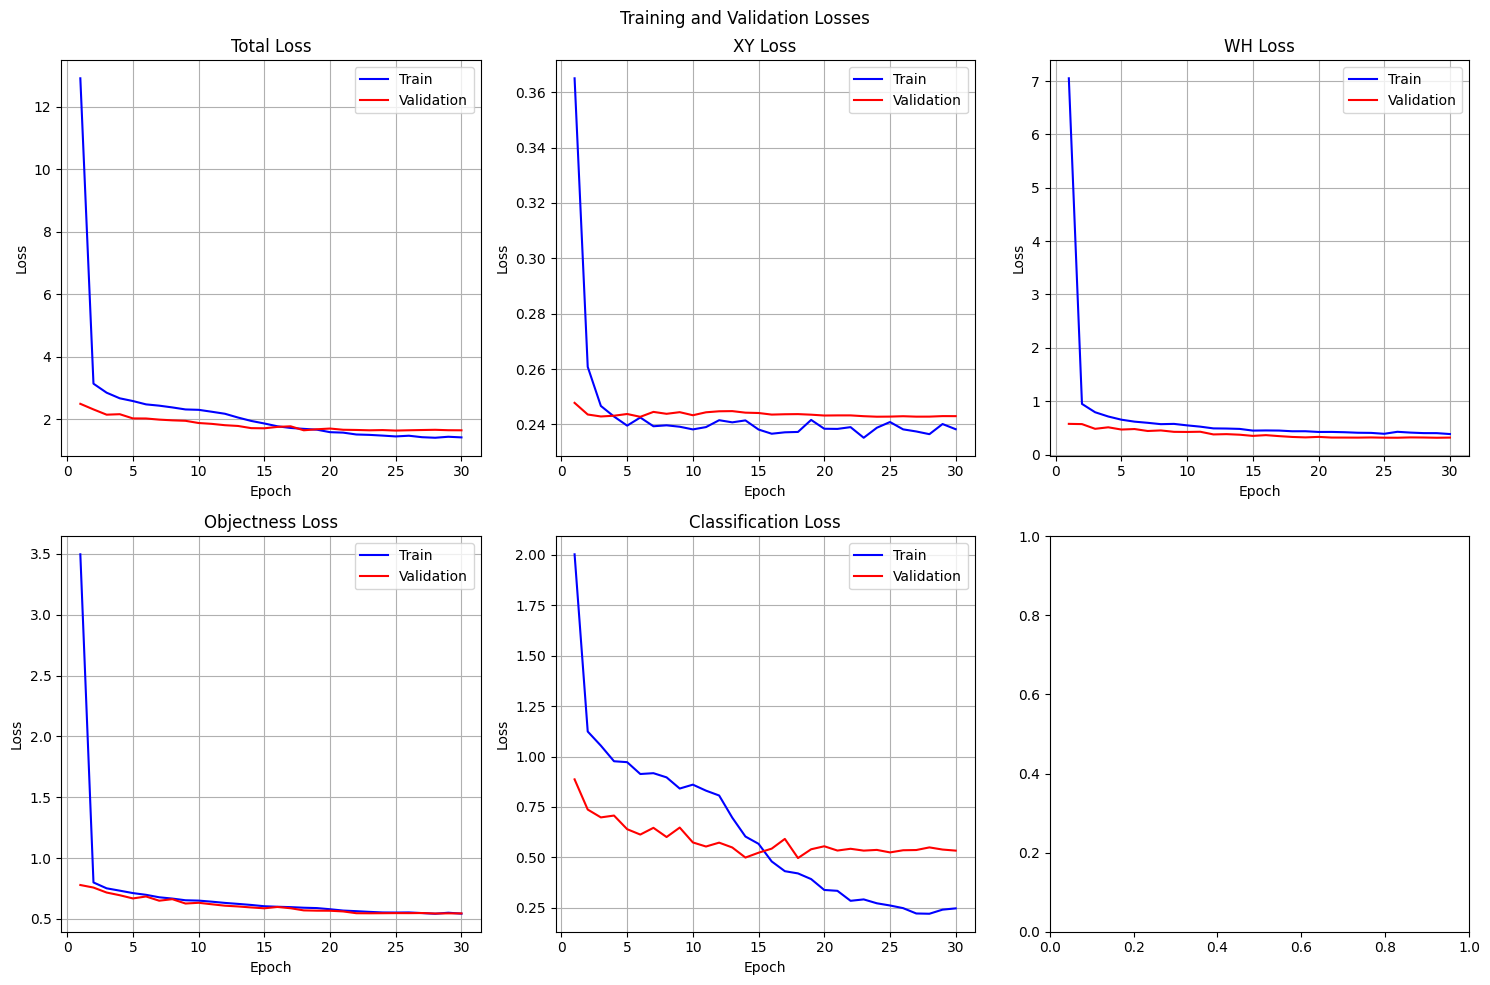

In [15]:
def save_checkpoint(model, optimizer, epoch, loss, filepath):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }, filepath)

def load_checkpoint(model, optimizer, filepath):
    checkpoint = torch.load(filepath)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']
    return epoch, loss

def plot_losses(train_losses, val_losses, save_path=None):
    import matplotlib.pyplot as plt
    epochs = range(1, len(train_losses['total']) + 1)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Training and Validation Losses')
    
    loss_types = ['total', 'xy', 'wh', 'obj', 'cls']
    titles = ['Total Loss', 'XY Loss', 'WH Loss', 'Objectness Loss', 'Classification Loss']
    
    for i, (loss_type, title) in enumerate(zip(loss_types, titles)):
        ax = axes[i//3, i%3]
        ax.plot(epochs, train_losses[loss_type], 'b-', label='Train')
        ax.plot(epochs, val_losses[loss_type], 'r-', label='Validation')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(True)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def main():
    print(f"Using device: {experiment_config['device']}")
    device = torch.device(experiment_config['device'])
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_dir = Path("checkpoints") / timestamp
    save_dir.mkdir(parents=True, exist_ok=True)

    print(f"Training samples: {len(train_loader.dataset)}")
    print(f"Validation samples: {len(val_loader.dataset)}")
    
    model = SimpleResNetYOLO(
        anchor_boxes=anchors,
        target_size=experiment_config['target_size'][0],
        unfreeze_partial_epoch=experiment_config['unfreeze_partial_epoch'],
        unfreeze_all_epoch=experiment_config['unfreeze_all_epoch'],
        grid_size=experiment_config['grid_size'],
        dropout_rate=experiment_config['dropout_rate']
    ).to(device)
    
    info = model.get_model_info()
    print("Model Information:")
    for key, value in info.items():
        print(f"  {key}: {value:,}" if isinstance(value, int) else f"  {key}: {value}")
    
    optimizer = torch.optim.AdamW(
        model.parameters(), 
        lr=experiment_config['lr_frozen'], 
        weight_decay=experiment_config['weight_decay']
    )
    
    train_history = {'total': [], 'xy': [], 'wh': [], 'obj': [], 'cls': []}
    val_history = {'total': [], 'xy': [], 'wh': [], 'obj': [], 'cls': []}
    
    best_val_loss = float('inf')
    
    for epoch in range(1, experiment_config['num_epochs'] + 1):
        print(f"\nEpoch {epoch}/{experiment_config['num_epochs']}")
        print("-" * 50)
        
        train_losses = train_epoch(model, anchors, train_loader, optimizer, device, epoch)
        val_losses = validate_epoch(model, anchors, val_loader, device)
        
        print(f"Train - Total: {train_losses['total']:.4f}, "
              f"XY: {train_losses['xy']:.4f}, "
              f"WH: {train_losses['wh']:.4f}, "
              f"Obj: {train_losses['obj']:.4f}, "
              f"Cls: {train_losses['cls']:.4f}")
        
        print(f"Val   - Total: {val_losses['total']:.4f}, "
              f"XY: {val_losses['xy']:.4f}, "
              f"WH: {val_losses['wh']:.4f}, "
              f"Obj: {val_losses['obj']:.4f}, "
              f"Cls: {val_losses['cls']:.4f}")
        
        print(f"Current LR: {optimizer.param_groups[0]['lr']:.1e}")
        
        for key in train_history:
            train_history[key].append(train_losses[key])
            val_history[key].append(val_losses[key])
        
        if val_losses['total'] < best_val_loss:
            best_val_loss = val_losses['total']
            save_checkpoint(
                model, optimizer, epoch, val_losses['total'],
                save_dir / 'best_model.pth'
            )
            print(f"Saved best model with validation loss: {best_val_loss:.4f}")

        if epoch == experiment_config['num_epochs']:
            save_checkpoint(
                model, optimizer, epoch, train_losses['total'],
                save_dir / 'last_epoch.pth'
            )
            print(f"Saved last epoch with training loss: {train_losses['total']:.4f}")

    plot_losses(train_history, val_history, 
                save_path=save_dir / 'training_curves.png')
    with open(save_dir / "experiment_config.json", "w") as f:
        json.dump(experiment_config, f, indent=2)
    
main()

MPS available: Using Apple Silicon GPU
{'model': 'resnet50', 'num_anchors': 3, 'grid_size': 14, 'batch_size': 8, 'num_epochs': 30, 'val_ratio': 0.2, 'unfreeze_partial_epoch': 12, 'unfreeze_all_epoch': 24, 'device': 'mps', 'target_size': (448, 448), 'lr_frozen': 0.001, 'lr_partial': 1e-05, 'lr_all': 1e-06, 'weight_decay': 0.001, 'dropout_rate': 0.4, 'use_augmentation': True, 'use_bg_removal': True, 'bg_removal_p': 0.5, 'coord_weight': 1, 'augmentation_strength': 0.5}


Using cache found in /Users/tobysmith/.cache/torch/hub/pytorch_vision_v0.10.0


ResNet50 configured for 14x14 grid
Output channels: 2048
Backbone parameters: 23.5M
Backbone frozen
Loaded model from checkpoints/20250816_191616/best_model.pth
Model was trained for 30 epochs
Best validation loss: 1.3030
Loaded anchors from model: tensor([[ 2.2801,  2.5578],
        [ 5.7874,  6.7110],
        [10.2309, 10.9251]], device='mps:0')
Image 1: ./cat_dog_images/000000000575.jpg
  Detections: 3
  Cats: 1, Dogs: 0


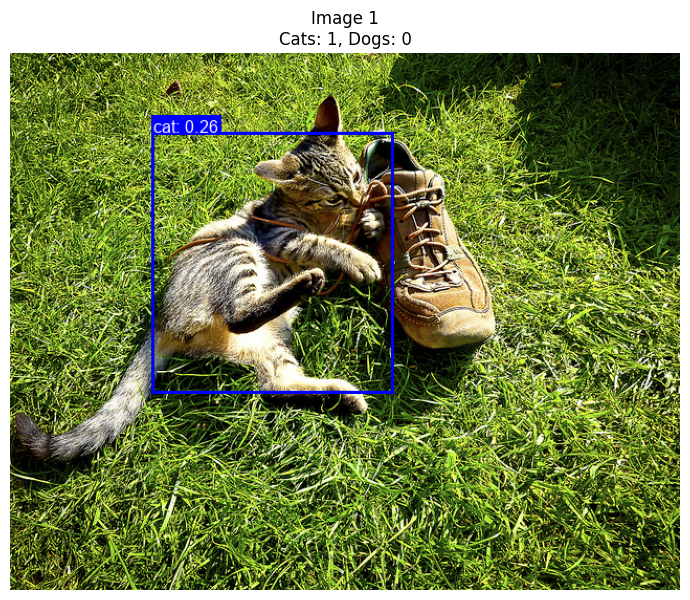

In [31]:
def load_model_for_inference(model_path, device='cpu'):
    print(experiment_config)
    dummy_anchors = torch.ones(experiment_config['num_anchors'], 2)
    model = SimpleResNetYOLO(
        dummy_anchors,
        experiment_config['target_size'][0],
        grid_size=experiment_config['grid_size']
    ).to(device)
    
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    print(f"Loaded model from {model_path}")
    print(f"Model was trained for {checkpoint['epoch']} epochs")
    print(f"Best validation loss: {checkpoint['loss']:.4f}")
    print(f"Loaded anchors from model: {model.anchors}")
    
    return model

def inference_on_images(model, image_paths, device='cpu', conf_threshold=0.2, target_size=(448, 448)):
    from PIL import Image, ImageDraw, ImageFont
    import torchvision.transforms as transforms
    
    anchors = model.anchors
    
    if isinstance(image_paths, str):
        image_paths = [image_paths]
    
    transform = transforms.Compose([
        transforms.Resize(target_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    class_names = {0: 'dog', 1: 'cat'}
    colors = {0: 'red', 1: 'blue'}
    
    num_images = len(image_paths)
    cols = min(3, num_images)
    rows = (num_images + cols - 1) // cols
    
    _, axes = plt.subplots(rows, cols, figsize=(7*cols, 7*rows))
    if num_images == 1:
        axes = [axes]
    elif rows == 1:
        axes = [axes] if cols == 1 else axes
    else:
        axes = axes.flatten()
    
    model.eval()
    with torch.no_grad():
        for idx, image_path in enumerate(image_paths):
            original_image = Image.open(image_path).convert('RGB')
            original_size = original_image.size
            
            input_tensor = transform(original_image).unsqueeze(0).to(device)
            
            predictions = model(input_tensor)
            
            detections = decode_yolo_predictions(predictions, anchors, conf_threshold=conf_threshold,
                                                  grid_size=experiment_config['grid_size'],image_size=experiment_config['target_size'][0])[0]            
           
            detections = nms(detections['boxes'], detections['scores'], detections['labels'], 0.2)
            scale_x = original_size[0] / target_size[0]
            scale_y = original_size[1] / target_size[1]
            
            draw_image = original_image.copy()
            draw = ImageDraw.Draw(draw_image)
            
            detection_count = {'cat': 0, 'dog': 0}
            
            if len(detections) > 0:
                boxes = detections['boxes']
                scores = detections['scores']
                labels = detections['labels']

                for i in range(len(boxes)):
                    x1, y1, x2, y2 = boxes[i]
                    conf = scores[i]
                    cls = labels[i]
                    
                    x1 = int(x1 * scale_x)
                    y1 = int(y1 * scale_y)
                    x2 = int(x2 * scale_x)
                    y2 = int(y2 * scale_y)
                    
                    class_id = int(cls)
                    class_name = class_names[class_id]
                    color = colors[class_id]
                    detection_count[class_name] += 1
 
                    draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
                    
                    label = f'{class_name}: {conf:.2f}'
                    
                    try:
                        font = ImageFont.truetype("/System/Library/Fonts/Arial.ttf", 16)
                    except:
                        font = ImageFont.load_default()
                    
                    bbox = draw.textbbox((0, 0), label, font=font)
                    text_width = bbox[2] - bbox[0]
                    text_height = bbox[3] - bbox[1]
                    
                    draw.rectangle([x1, y1-text_height-4, x1+text_width+4, y1], fill=color)
                    draw.text((x1+2, y1-text_height-2), label, fill='white', font=font)
            
            ax = axes[idx] if num_images > 1 else axes[0]
            ax.imshow(draw_image)
            ax.set_title(f'Image {idx+1}\nCats: {detection_count["cat"]}, Dogs: {detection_count["dog"]}')
            ax.axis('off')
            
            print(f"Image {idx+1}: {image_path}")
            print(f"  Detections: {len(detections) if len(detections) > 0 else 0}")
            print(f"  Cats: {detection_count['cat']}, Dogs: {detection_count['dog']}")
    
    for idx in range(num_images, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Example usage:
# Load your trained model (anchors automatically loaded from model)
model_path = "checkpoints/20250816_191616/best_model.pth"
device = get_device()

# Load the model - anchors are now loaded automatically from the saved model
model = load_model_for_inference(model_path, device)

# Test on single image
inference_on_images(model, "./cat_dog_images/000000000575.jpg", device)

# Test on m
# ultiple images
# image_paths = ["path/to/image1.jpg", "path/to/image2.jpg", "path/to/image3.jpg"]
# inference_on_images(model, image_paths, device)